# 📊 Advanced Customer Churn Prediction System
### Senior Data Science Level Project

Includes:
- EDA
- Feature Engineering
- Model Training (RF, XGBoost)
- Hyperparameter Tuning
- ROC-AUC Evaluation
- Feature Importance
- Pipeline


In [ ]:
# Install required libraries (if needed)
# !pip install pandas numpy scikit-learn xgboost seaborn matplotlib

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

## Load Dataset

In [2]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data Cleaning

In [3]:
df.drop('customerID', axis=1, inplace=True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.fillna(df.median(numeric_only=True), inplace=True)

# Encode target
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

## EDA

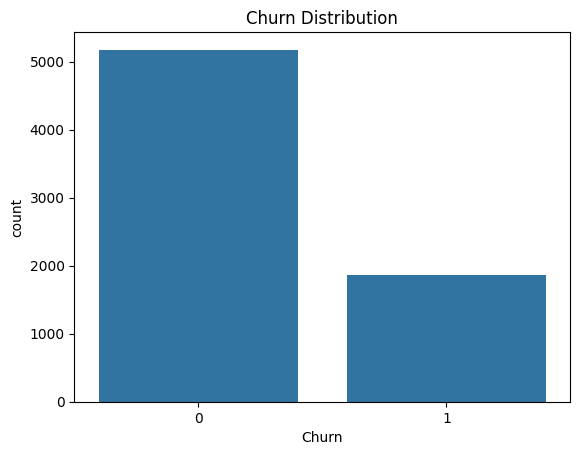

In [4]:
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

## Feature Engineering

In [5]:
categorical_cols = df.select_dtypes(include='object').columns
numeric_cols = df.select_dtypes(exclude='object').drop('Churn', axis=1).columns

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

/tmp/ipykernel_36497/2696609503.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


## Train-Test Split

In [6]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)

(5634, 19) (1409, 19)


## Model Pipeline + Hyperparameter Tuning

In [7]:
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 5],
    'model__learning_rate': [0.01, 0.1]
}

grid = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', verbose=1)
grid.fit(X_train, y_train)

print('Best Params:', grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits


/home/basha/Documents/ML1/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/basha/Documents/ML1/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/basha/Documents/ML1/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/basha/Documents/ML1/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:36] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain,

Best Params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}


/home/basha/Documents/ML1/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/basha/Documents/ML1/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [23:28:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Evaluation

In [8]:
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.68      0.53      0.60       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.74      1409
weighted avg       0.80      0.81      0.80      1409

ROC-AUC: 0.8450528300911933


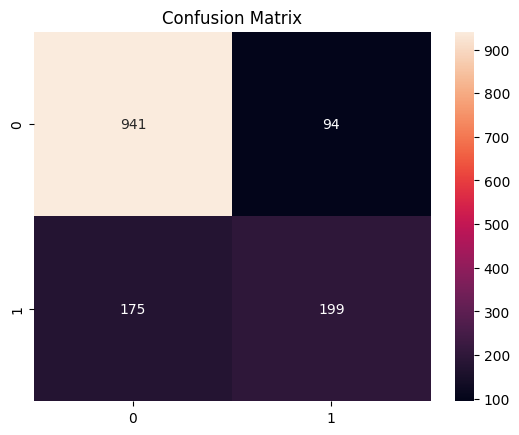

In [9]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()

## Feature Importance

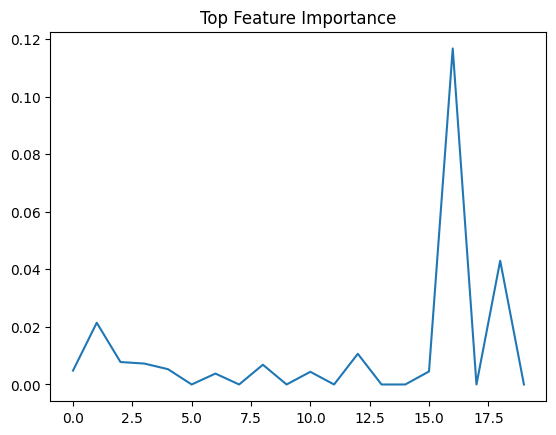

In [10]:
model = grid.best_estimator_.named_steps['model']

importances = model.feature_importances_
plt.plot(importances[:20])
plt.title('Top Feature Importance')
plt.show()